In [68]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import sys
sys.path.append("/n/home12/binxuwang/Github/NHP_NSD_analysis")
# from data_loader import NSDDataLoader
from os.path import join
import h5py
from scipy import ndimage
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from NSD_utils.h5_dataset_utils import load_data_from_GoodUnitStrc
from NSD_utils.image_utils import pil_images_to_grid

In [69]:
NSD_root = f"/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/Datasets/NSD_N3"
h5_file = h5py.File(join(NSD_root, "GoodUnit_240709_JianJian_NSD1000_LOC_g2.mat"), "r")
GoodUnit_struct = load_data_from_GoodUnitStrc(h5_file)

trial_valid_idx (4460, 1)
dataset_valid_idx (4460, 1)
Raster (675, 450, 4308)
response_matrix_img (675, 450, 1072)
unittype (675,)
KSidx (675,)
spikepos (675, 2)
PsthRange (450,)


In [89]:
!ls {NSD_root}

drive-download-20250715T201056Z-1-001.zip
drive-download-20250715T201056Z-1-002.zip
drive-download-20250715T201056Z-1-003.zip
drive-download-20250715T201056Z-1-004.zip
drive-download-20250715T201056Z-1-005.zip
drive-download-20250715T201056Z-1-006.zip
drive-download-20250715T201056Z-1-007.zip
drive-download-20250715T201056Z-1-008.zip
drive-download-20250715T201056Z-1-009.zip
drive-download-20250715T201056Z-1-010.zip
GoodUnit_240629_JianJian_NSD1000_LOC_g2.mat
GoodUnit_240708_JianJian_NSD1000_LOC_g2.mat
GoodUnit_240709_JianJian_NSD1000_LOC_g2.mat
GoodUnit_240711_FaCai_NSD1000_LOC_g4.mat
GoodUnit_240719_FaCai_NSD1000_LOC_g3.mat
GoodUnit_240720_FaCai_NSD1000_LOC_g2.mat
GoodUnit_240722_FaCai_NSD1000_LOC_g0.mat
GoodUnit_240724_TuTu_NSD1000_LOC_g2.mat
GoodUnit_240725_FaCai_NSD1000_LOC_g1.mat
GoodUnit_240726_TuTu_NSD1000_LOC_g3.mat
GoodUnit_240728_JianJian_NSD1000_LOC_g3.mat
GoodUnit_240730_JianJian_NSD1000_LOC_g2.mat
GoodUnit_240801_JianJian_NSD1000_LOC_g1.mat
GoodUnit_240807_FaCai_NSD1000_L

In [70]:
list(GoodUnit_struct)

['exp_subject',
 'trial_valid_idx',
 'dataset_valid_idx',
 'Raster',
 'response_matrix_img',
 'PsthRange',
 'unittype',
 'KSidx',
 'spikepos',
 'n_units',
 'n_timepoints',
 'n_valid_trials',
 'n_trials',
 'n_images']

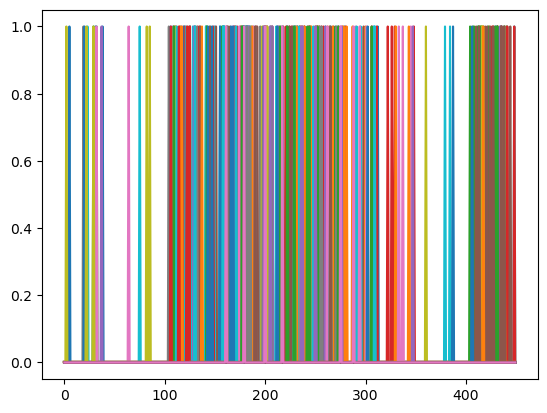

In [94]:
Raster = GoodUnit_struct["Raster"]
plt.plot(Raster[4,:,::50])
plt.show()

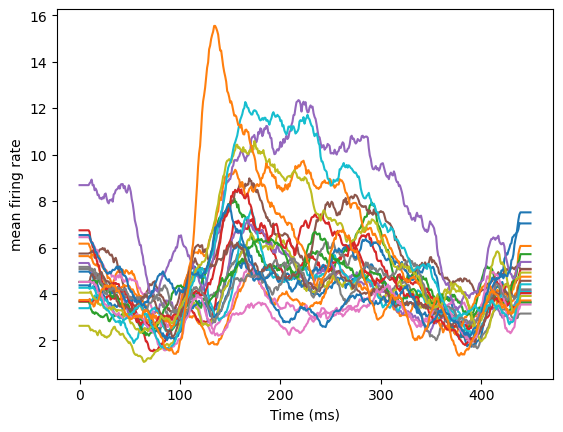

In [24]:
response_matrix_img = GoodUnit_struct["response_matrix_img"]
plt.plot(response_matrix_img[:,:,::50].mean(axis=0)) # 
plt.ylabel("mean firing rate")
plt.xlabel("Time (ms)")
plt.show()

In [91]:
import torch
torch.save(torch.from_numpy(response_matrix_img), f"GoodUnit_240709_JianJian_NSD1000_LOC_g2_response_matrix_img.pt")

### Dimensionality of the response

In [35]:
response_matrix_img.shape # n_neurons, n_time_bins, n_images
S_col = []
for t in range(150, response_matrix_img.shape[1], 50):
    response_matrix_img_tbin = response_matrix_img[:,t:t+50,:].mean(axis=1) # 
    cov_mat = np.cov(response_matrix_img_tbin, rowvar=True)
    # print(cov_mat.shape)
    # break
    # rs_mat  = np.corrcoef(response_matrix_img_tbin, rowvar=False)
    # U, S, V = np.linalg.svd(response_matrix_img_tbin)
    eig_vals, eig_vecs = np.linalg.eigh(cov_mat)
    S_col.append(eig_vals[::-1])

In [ ]:
plt.figure(figsize=(5, 5))
for i, t in enumerate(range(150, response_matrix_img.shape[1], 50)):
    S = S_col[i]
    plt.plot(range(1, len(S[:200])+1), S[:200] / np.sum(S), label=f"t={t}")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.show()

In [ ]:
response_matrix_img.shape # n_neurons, n_time_bins, n_images
S_col = []
for t in range(150, response_matrix_img.shape[1], 50):
    response_matrix_img_tbin = response_matrix_img[:,t:t+50,:].mean(axis=1) # 
    cov_mat = np.cov(response_matrix_img_tbin, rowvar=True)
    # print(cov_mat.shape)
    # break
    # rs_mat  = np.corrcoef(response_matrix_img_tbin, rowvar=False)
    # U, S, V = np.linalg.svd(response_matrix_img_tbin)
    eig_vals, eig_vecs = np.linalg.eigh(cov_mat)
    S_col.append(eig_vals[::-1])
plt.figure(figsize=(5, 5))
for i, t in enumerate(range(150, response_matrix_img.shape[1], 50)):
    S = S_col[i]
    plt.plot(range(1, len(S[:200])+1), S[:200] / np.sum(S), label=f"t={t}")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.show()

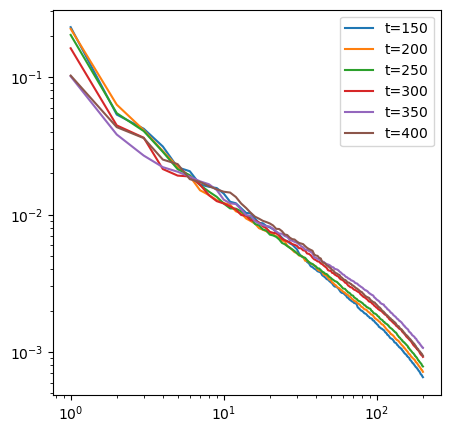

In [38]:
plt.figure(figsize=(5, 5))
for i, t in enumerate(range(150, response_matrix_img.shape[1], 50)):
    S = S_col[i]
    plt.plot(range(1, len(S[:200])+1), S[:200] / np.sum(S), label=f"t={t}")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.show()

In [ ]:
import numpy as np

def hoyer_score(X, axis=1, eps=1e-12):
    """
    Compute Hoyer sparsity score along a given axis (vectorized).
    
    Parameters
    ----------
    X : np.ndarray
        Input array of shape (n_samples, n_features) or (n_features,).
    axis : int
        Axis along which to compute the score.
        axis=1 → per row (default)
        axis=0 → per column
    eps : float
        Small constant to avoid division by zero.
    
    Returns
    -------
    np.ndarray
        Hoyer score(s) in [0, 1], same shape as np.sum(X, axis=axis, keepdims=False).
    """
    X = np.asarray(X)
    n = X.shape[axis]
    l1 = np.sum(np.abs(X), axis=axis)
    l2 = np.sqrt(np.sum(X**2, axis=axis)) + eps  # avoid divide-by-zero
    score = (np.sqrt(n) - (l1 / l2)) / (np.sqrt(n) - 1)
    return np.clip(score, 0, 1)  # ensure numerical stability

In [40]:
hoyer_per_time_per_img = hoyer_score(response_matrix_img, axis=0)

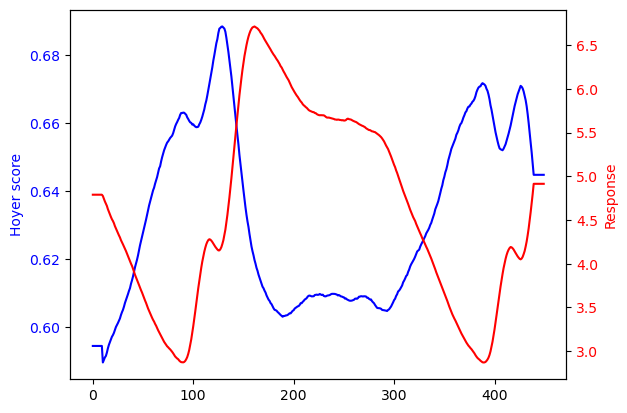

In [ ]:
fig, ax1 = plt.subplots()
ax1.plot(hoyer_per_time_per_img.mean(axis=1), 'b-', label='Hoyer score')
ax1.set_ylabel('Hoyer score', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(response_matrix_img.mean(axis=(0,2)), 'r-', label='Response')
ax2.set_ylabel('Response', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.show()

In [47]:
hoyer_per_time_per_img_mean_sub = hoyer_score(response_matrix_img - response_matrix_img.mean(axis=(1,2), keepdims=True), axis=0)

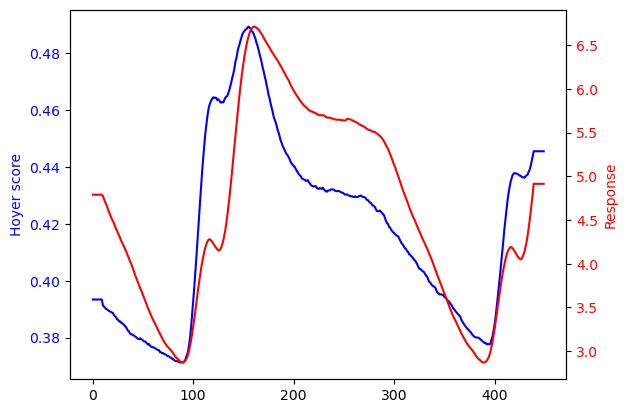

In [48]:
fig, ax1 = plt.subplots()
ax1.plot(hoyer_per_time_per_img_mean_sub.mean(axis=1), 'b-', label='Hoyer score mean-sub')
ax1.set_ylabel('Hoyer score', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(response_matrix_img.mean(axis=(0,2)), 'r-', label='Response')
ax2.set_ylabel('Response', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.show()

In [49]:
hoyer_per_time_per_img_zscore = hoyer_score((response_matrix_img - response_matrix_img.mean(axis=(1,2), keepdims=True)) / response_matrix_img.std(axis=(1,2), keepdims=True), axis=0)

In [51]:
response_matrix_img_zscore = (response_matrix_img - response_matrix_img.mean(axis=(1,2), keepdims=True)) / response_matrix_img.std(axis=(1,2), keepdims=True)

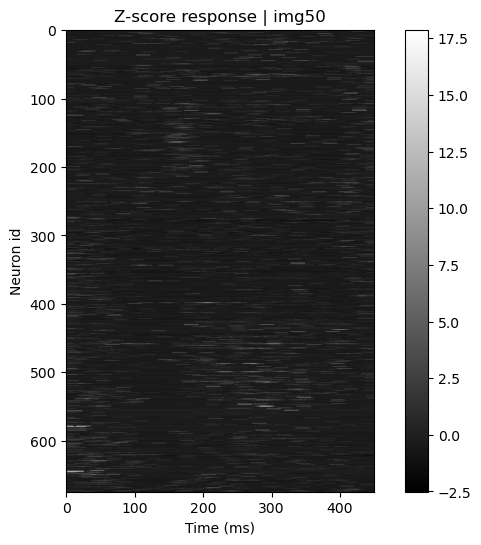

In [63]:
imgid = 50
plt.figure(figsize=(8, 6))
plt.imshow(response_matrix_img_zscore[:,:,imgid], cmap="gray")
plt.ylabel("Neuron id")
plt.xlabel("Time (ms)")
plt.title(f"Z-score response | img{imgid}")
plt.colorbar()
plt.show()

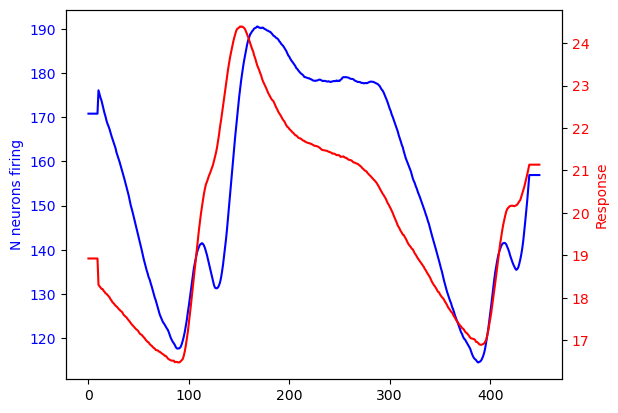

In [65]:
num_neuron_firing = (response_matrix_img > 0).sum(axis=0).mean(axis=1)
sum_firing_rate = response_matrix_img.sum(axis=(0)).mean(axis=1)
mean_firing_rate_per_neuron = sum_firing_rate / num_neuron_firing

fig, ax1 = plt.subplots()
ax1.plot(num_neuron_firing, 'b-', label='N neurons firing')
ax1.set_ylabel('N neurons firing', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(mean_firing_rate_per_neuron, 'r-', label='Response')
ax2.set_ylabel('Response', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.show()

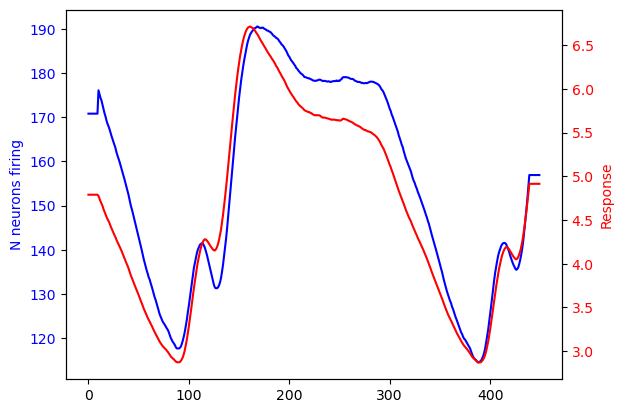

In [64]:
num_neuron_firing = (response_matrix_img > 0).sum(axis=0).mean(axis=1)
fig, ax1 = plt.subplots()
ax1.plot(num_neuron_firing, 'b-', label='N neurons firing')
ax1.set_ylabel('N neurons firing', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(response_matrix_img.mean(axis=(0,2)), 'r-', label='Response')
ax2.set_ylabel('Response', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.show()

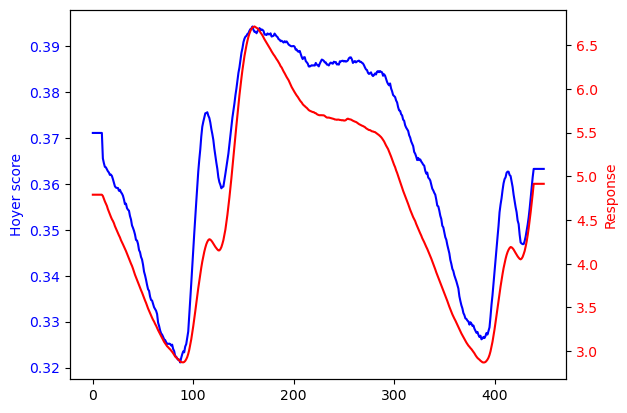

In [50]:
fig, ax1 = plt.subplots()
ax1.plot(hoyer_per_time_per_img_zscore.mean(axis=1), 'b-', label='Hoyer score zscore')
ax1.set_ylabel('Hoyer score', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(response_matrix_img.mean(axis=(0,2)), 'r-', label='Response')
ax2.set_ylabel('Response', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.show()

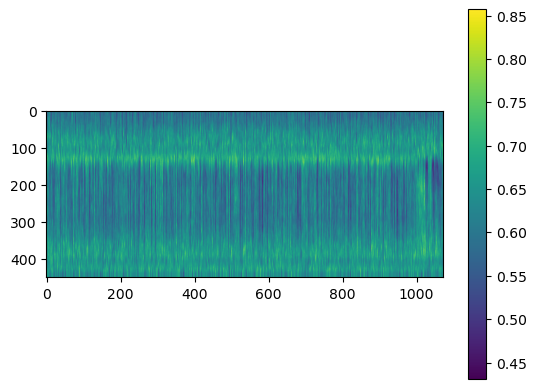

In [42]:
plt.imshow(hoyer_per_time_per_img)
plt.colorbar()

In [72]:
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
stimdir = join(NSD_root, "NSD1000_LOC")

vis_transform = None
# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
# Create dataset using ImageFolder
nsd_dataset = ImageFolder(root=NSD_root, transform=None)
print(f"Dataset size: {len(nsd_dataset)}")
print(f"Classes: {nsd_dataset.classes}")
# Create dataloader
dataloader = DataLoader(nsd_dataset, batch_size=32, shuffle=False)

Dataset size: 1072
Classes: ['NSD1000_LOC']


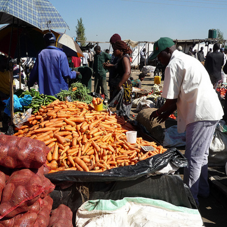

In [88]:
nsd_dataset[0][0]

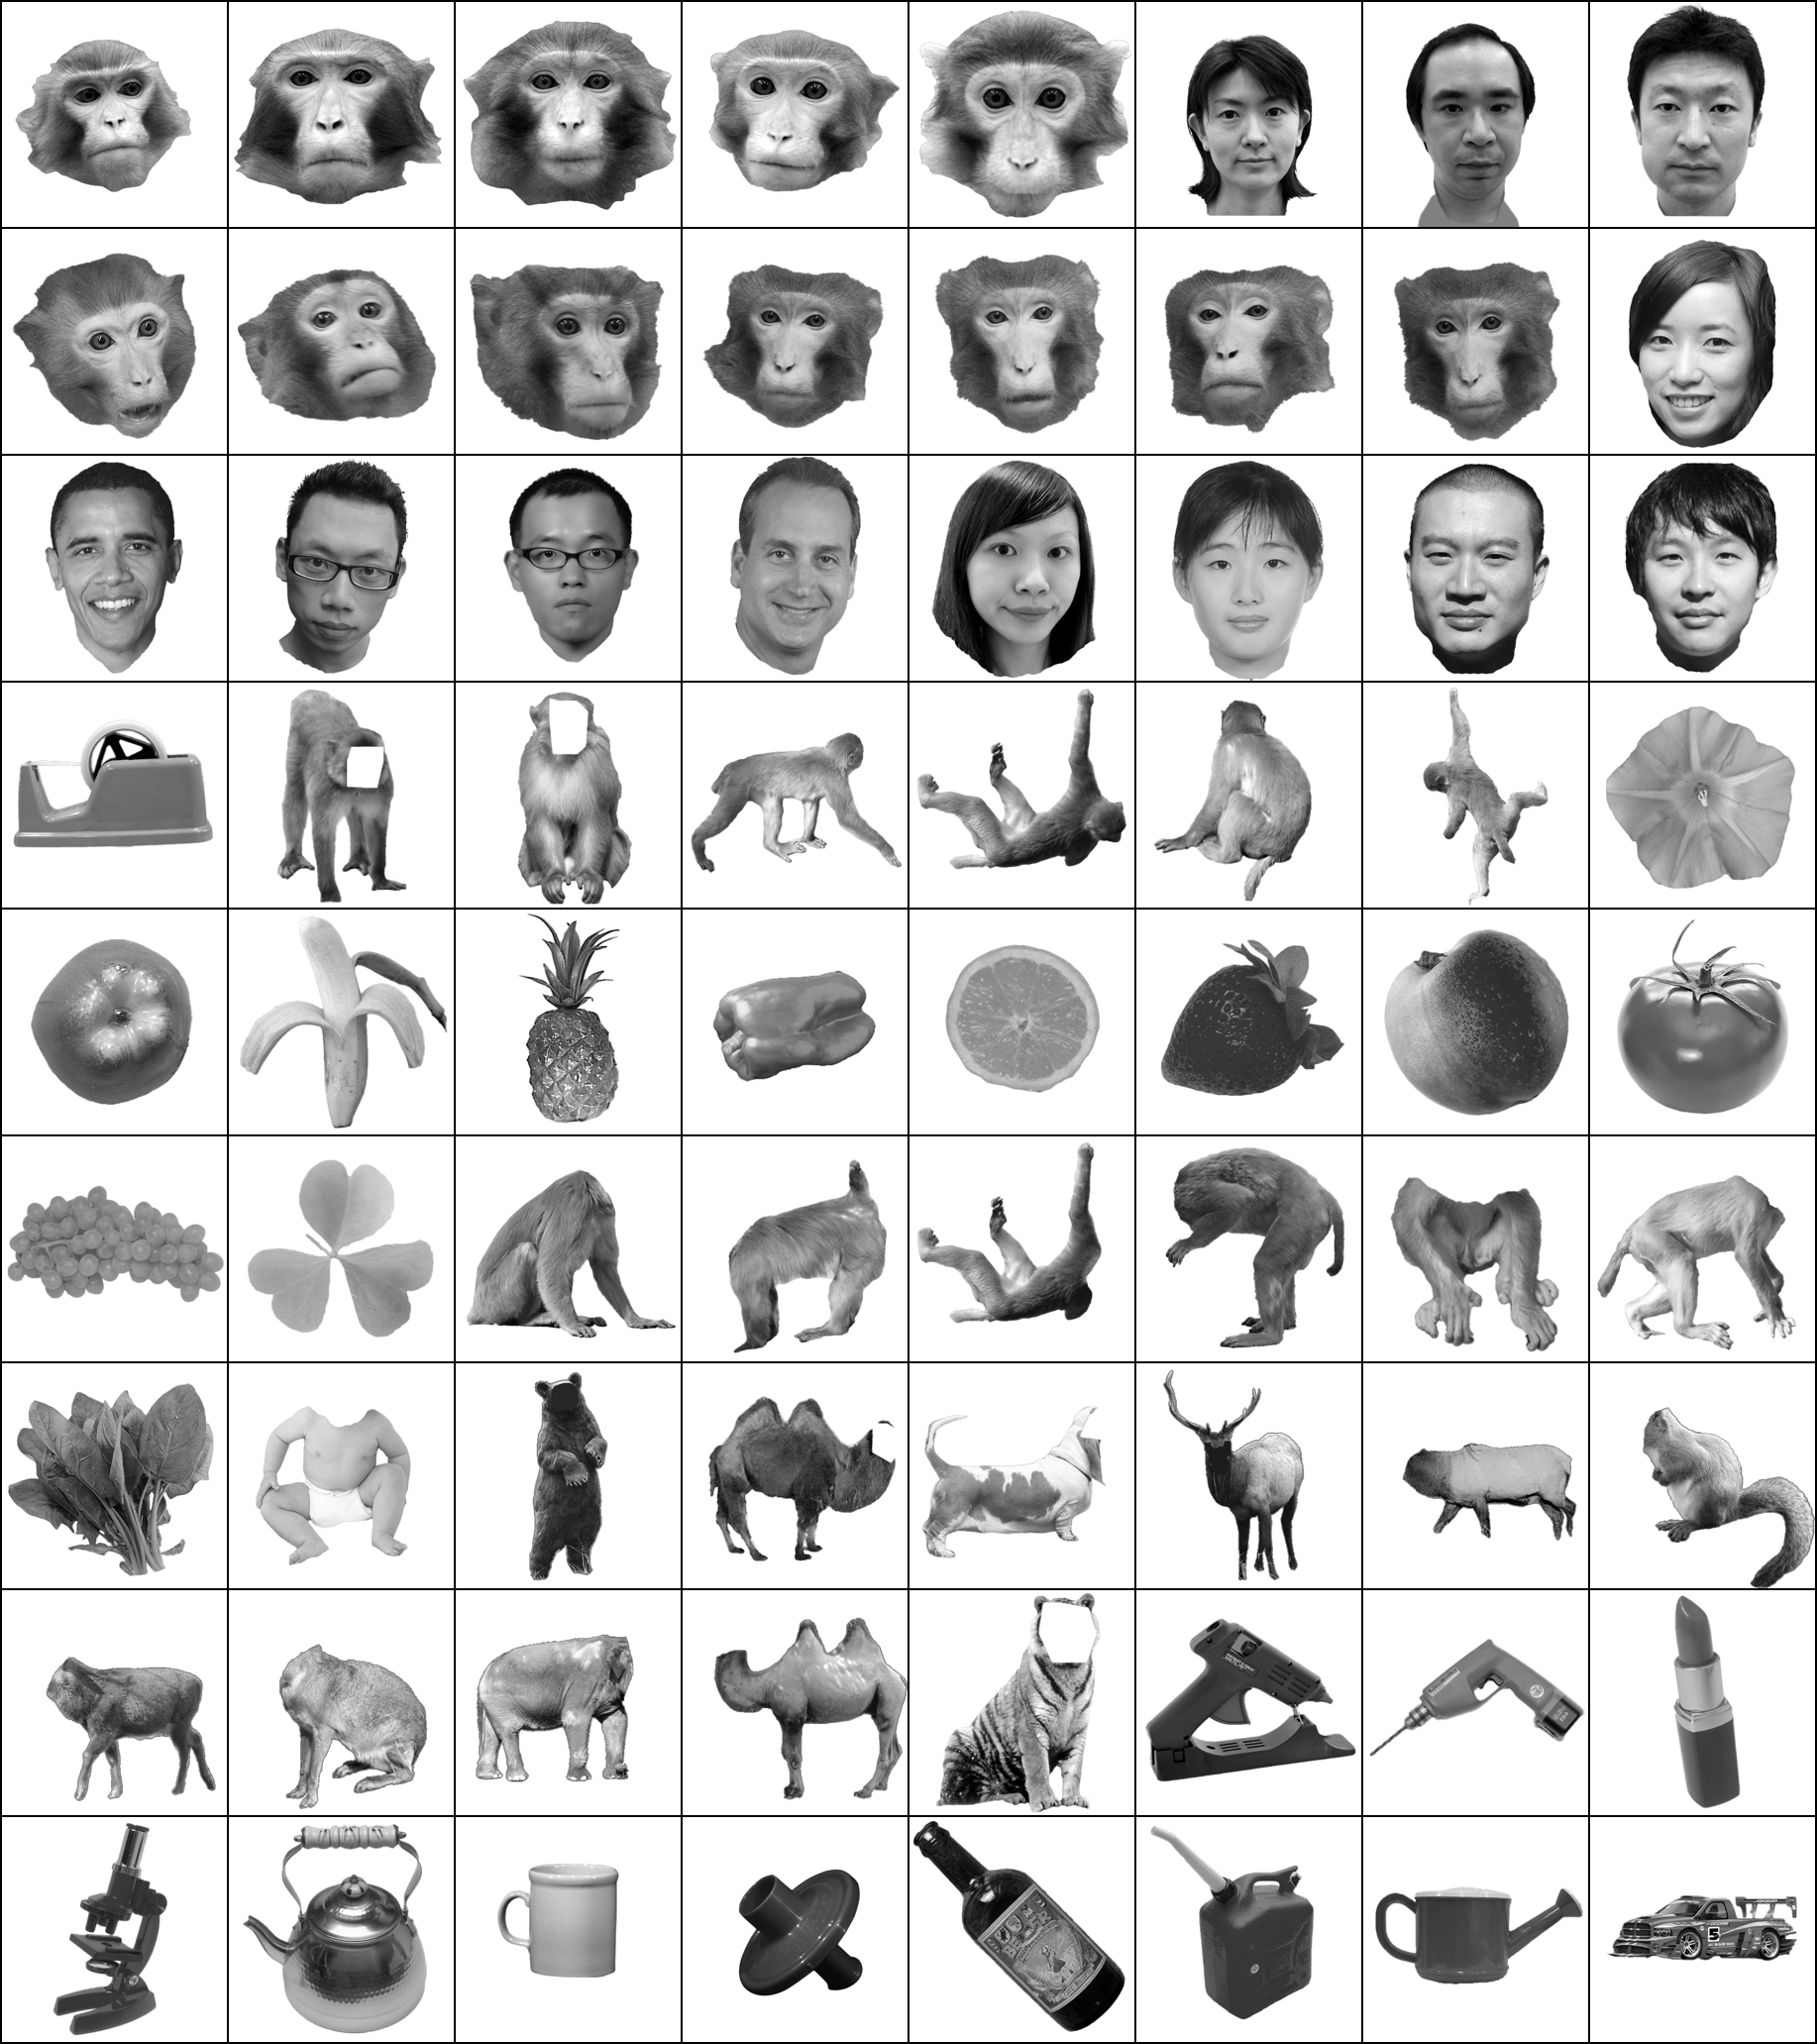

In [83]:
sorted_imgs = [nsd_dataset[img_idx][0] for img_idx in range(1000, 1072)]
pil_images_to_grid(sorted_imgs, grid_size=(8, 9))